# 01. 상품 사진 → 설명·태그·검색 키워드

**실습 목표**  
상품 이미지를 입력해 이미지 캡션을 생성하고, 후보 상품 카테고리를 Zero-shot 방식으로 점수화한다.

**주요 Hugging Face 모델**  
`Salesforce/blip-image-captioning-base + google/siglip-base-patch16-224`

> 이 노트북은 **파인튜닝 없이 사전학습 모델을 추론에 활용**하는 실습이다.  
> RTX 4060 8GB 환경을 고려했으며, CUDA가 없으면 CPU로 자동 전환하도록 구성하였다.

In [1]:
# uv add transformers accelerate pillow requests

In [2]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", TORCH_DEVICE)

PyTorch: 2.14.0+cu126
CUDA available: True
device: cuda


# 이미지 로딩 

In [3]:
from PIL import Image
import requests
from io import BytesIO

def load_image(url):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")

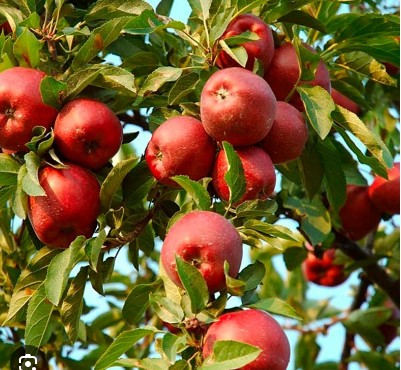

In [8]:
# IMAGE_URL = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
# image = load_image(IMAGE_URL)
# display(image)

from PIL import Image
image = Image.open("images/apples.jpg").convert("RGB")
display(image)

# 이미지를 입력받아 Captionning 출력

In [12]:
from transformers import pipeline

captioner = pipeline(
    "image-text-to-text",
    model="Salesforce/blip-image-captioning-base",
    device=DEVICE
)
result = captioner(
    images=image,
    text="Describe this image.",
    max_new_tokens=40
)

print("Caption:", result)
# print("Caption:", result[0]["generated_text"])

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Caption: [{'input_text': 'Describe this image.', 'generated_text': 'Describe this image. apples'}]


In [ ]:
# 저장위치:  /home/사용자명/.cache/huggingface/hub

# 각 후보 라벨과의 의미적 유사도를 계산하고 점수를 반환

In [ ]:
# 이미지를 입력받아 각 후보 라벨과의 의미적 유사도를 계산하고 점수를 반환
classifier = pipeline(
    "zero-shot-image-classification",
    model="google/siglip-base-patch16-224",
    device=DEVICE
)

# 후보 범주 목록
candidate_labels = [
    "pet", "fashion item", "food", "electronics",
    "furniture", "vehicle", "outdoor product"
]
scores = classifier(image, candidate_labels=candidate_labels)
scores[:5]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

[{'score': 2.6949246603180654e-05, 'label': 'food'},
 {'score': 8.08858203527052e-06, 'label': 'outdoor product'},
 {'score': 7.759480240565608e-07, 'label': 'pet'},
 {'score': 3.974090532210539e-07, 'label': 'fashion item'},
 {'score': 1.9376598459075467e-07, 'label': 'furniture'}]

In [15]:
tags = [x["label"] for x in scores[:3]]

keywords = list(dict.fromkeys(result[0]["generated_text"].lower().split() + tags))
print("추천 태그:", tags)
print("검색 키워드:", keywords[:12])

추천 태그: ['food', 'outdoor product', 'pet']
검색 키워드: ['describe', 'this', 'image.', 'apples', 'food', 'outdoor product', 'pet']


## 확장 과제
- 직접 촬영한 상품 이미지로 교체해본다.
- 후보 라벨을 쇼핑몰 카테고리 체계로 바꿔본다.
- 캡션·태그를 JSON 형태의 상품 메타데이터로 저장해본다.